In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

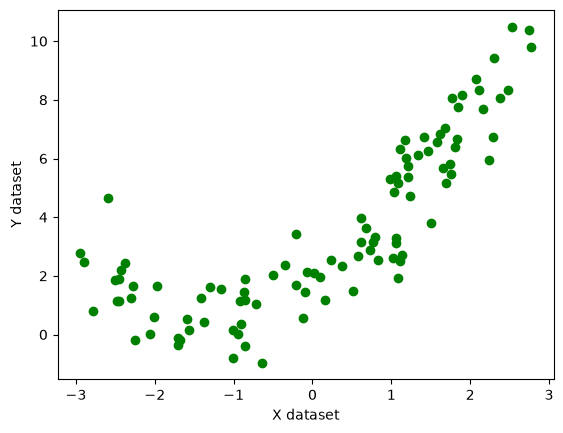

In [53]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
X_test

array([[ 1.68717779],
       [ 1.50366682],
       [ 1.8904962 ],
       [-2.50068982],
       [ 0.83248199],
       [-0.12115546],
       [ 1.18654779],
       [-0.86810991],
       [ 2.47307344],
       [-1.29563515],
       [ 2.37556799],
       [ 2.0786608 ],
       [-1.00916969],
       [-1.96568027],
       [ 1.65490094],
       [ 2.77195024],
       [-0.95021503],
       [ 1.82909533],
       [ 1.11439042],
       [ 0.57715101]])

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
regression=LinearRegression()
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
from sklearn.metrics import r2_score

score=r2_score(y_test,regression.predict(X_test))
score

0.6986569729427983

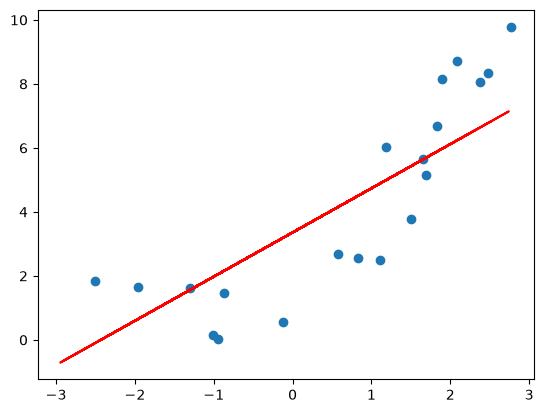

In [59]:
plt.plot(X_train,regression.predict(X_train),color='r')
plt.scatter(X_test,y_test)


In [60]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [61]:
X_train_poly

array([[ 1.00000000e+00, -2.58952268e+00,  6.70562771e+00],
       [ 1.00000000e+00, -2.78500016e+00,  7.75622590e+00],
       [ 1.00000000e+00,  7.28142371e-01,  5.30191312e-01],
       [ 1.00000000e+00,  6.16269532e-01,  3.79788136e-01],
       [ 1.00000000e+00, -9.55649574e-02,  9.13266109e-03],
       [ 1.00000000e+00,  2.29206114e+00,  5.25354425e+00],
       [ 1.00000000e+00,  1.08578984e+00,  1.17893957e+00],
       [ 1.00000000e+00, -2.27964034e+00,  5.19676007e+00],
       [ 1.00000000e+00, -2.47799961e+00,  6.14048204e+00],
       [ 1.00000000e+00,  6.77868094e-01,  4.59505153e-01],
       [ 1.00000000e+00,  1.84817594e+00,  3.41575432e+00],
       [ 1.00000000e+00,  1.08836844e+00,  1.18454585e+00],
       [ 1.00000000e+00, -1.41077144e+00,  1.99027606e+00],
       [ 1.00000000e+00, -3.53399742e-01,  1.24891378e-01],
       [ 1.00000000e+00,  9.83927989e-01,  9.68114288e-01],
       [ 1.00000000e+00,  2.16543734e+00,  4.68911888e+00],
       [ 1.00000000e+00,  7.63283159e-01

In [62]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8841136640278211


In [63]:
regression.intercept_

array([1.86511654])

In [64]:
regression.coef_

array([[0.       , 1.6434856, 0.597872 ]])

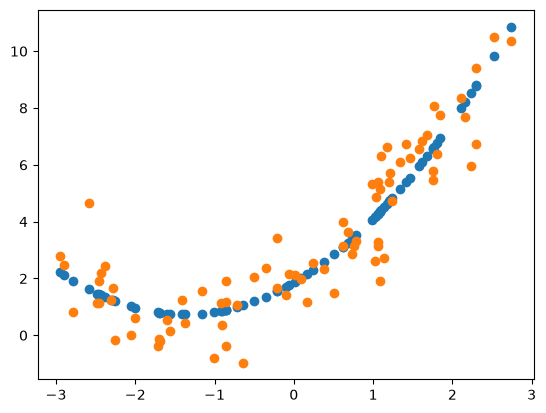

In [65]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [66]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

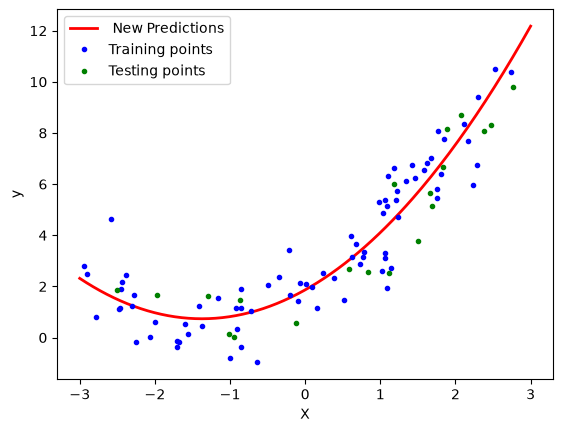

In [67]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [68]:
from sklearn.pipeline import Pipeline


In [70]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

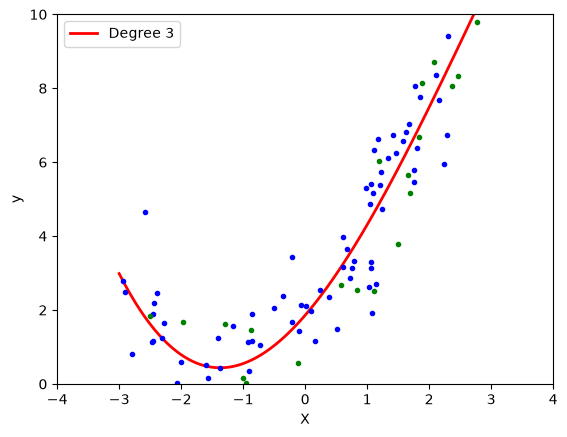

In [71]:
poly_regression(3)